# Project 4b — Module 5: Statistical Inference
## Lesson 1: Scientific Method, Hypotheses & Study Design

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 1 — Business Understanding |
| **Module** | 5 — Statistical Inference (Alkemy Bootcamp) |
| **Dataset** | PequeShop — customers_final.csv + transactions_final.csv |
| **Date** | 2026-03 |

---

> **Executive Summary:**  
> This notebook defines the statistical research agenda for PequeShop, a Chilean
> children's e-commerce. Building on EDA results from project-3 (churn=41.4%,
> avg_ticket=~$31,500 CLP, NPS=30.2), four formal hypotheses are formulated to
> validate whether these KPIs represent real population-level signals — not sample
> noise. The output directly gates entry into project-5 (Supervised ML), ensuring
> a garbage-in, garbage-out-free pipeline.


## Table of Contents

1. [CRISP-DM Phase 1 — Business Understanding](#1-crisp-dm-phase-1--business-understanding)
2. [Scientific Method — Step 1: Problem Definition](#2-scientific-method--step-1-problem-definition)
3. [Scientific Method — Step 2: Research Questions](#3-scientific-method--step-2-research-questions)
4. [Scientific Method — Step 3: Hypotheses](#4-scientific-method--step-3-hypotheses)
5. [Scientific Method — Step 4: Variable Identification](#5-scientific-method--step-4-variable-identification)
6. [Scientific Method — Step 5: Study Design](#6-scientific-method--step-5-study-design)
7. [LEAN Filter — Waste Elimination Review](#7-lean-filter--waste-elimination-review)
8. [Decisions Log — Lesson 1](#8-decisions-log--lesson-1)
9. [Next Steps — Lesson 2 Preview](#9-next-steps--lesson-2-preview)


---
## 1. CRISP-DM Phase 1 — Business Understanding

### 1.1 Context

PequeShop's analytical journey across CRISP-DM cycles:

| Project | Module | CRISP-DM Output | Role in Pipeline |
|---------|--------|-----------------|------------------|
| project-2 | M3 | ETL Pipeline → clean datasets | **Data source** |
| project-3 | M4 | EDA + OLS Regression → KPIs, correlations | **Prior knowledge** |
| **project-4b** (this) | **M5** | **Statistical Inference → validated KPIs** | **Current cycle** |
| project-5 | M6 | Supervised ML → spend prediction | Next cycle |

> **ICI Perspective (Industrial Engineering lens):**  
> Treating PequeShop as a production system, this project applies Statistical
> Process Control (SPC) logic: before optimizing outputs (project-5), we must
> confirm that the process measurements (KPIs) are statistically stable and
> meaningful — not artifacts of sample variation.

### 1.2 Requesting Unit

**Dirección de Analítica Comercial — PequeShop**  
Need: Validate KPIs from EDA with formal statistical tests before committing
budget to retention campaigns and platform investment decisions.


---
## 2. Scientific Method — Step 1: Problem Definition

### 2.1 Phenomenon Under Study

PequeShop customers exhibit heterogeneous purchase behavior. The EDA (project-3)
identified key patterns — but descriptive statistics describe the **sample**,
not the population. Before making business decisions, we need to answer:
*Are these patterns statistically significant, or could they be due to chance?*

### 2.2 Problem Statement

**PequeShop cannot confidently allocate its business budget** without knowing
whether the observed KPIs (churn rate, avg ticket, NPS-based differences) are
statistically distinguishable from benchmarks and between customer segments.

Without statistical validation:
- A churn rate of 41.4% might be within normal variation around a 30% benchmark
- The ticket difference between MercadoLibre and Shopify customers might be noise
- NPS-based pricing strategy might not be justified by the data


---
## 3. Scientific Method — Step 2: Research Questions

Research questions follow the **PICO framework** adapted for observational research:

| Element | PequeShop Definition |
|---------|---------------------|
| **P** — Population | PequeShop active customers (n=392) |
| **I** — Indicator | Customer KPIs: avg_ticket, churn, NPS |
| **C** — Comparison | Industry benchmarks + internal segment comparisons |
| **O** — Outcome | Evidence-based business decisions |

| # | Research Question | Type |
|---|-------------------|------|
| RQ1 | Is PequeShop's avg ticket significantly different from the Chilean e-commerce benchmark ($25,000 CLP)? | Inferential |
| RQ2 | Do MercadoLibre customers spend significantly more per transaction than Shopify customers? | Comparative |
| RQ3 | Is PequeShop's churn rate (41.4%) significantly higher than the industry benchmark of 30%? | Inferential (proportion) |
| RQ4 | Does avg ticket differ significantly across NPS segments (Promoters, Passives, Detractors)? | Comparative (3 groups) |


---
## 4. Scientific Method — Step 3: Hypotheses

Each hypothesis maps directly to a research question and a planned test in notebook 06.

---

### H1 — Average Ticket vs. Chilean E-commerce Benchmark

| | |
|--|--|
| **H₀** | Mean avg_ticket = $25,000 CLP (μ = 25000) |
| **H₁** | Mean avg_ticket ≠ $25,000 CLP (μ ≠ 25000) |
| **Test** | One-sample t-test (two-tailed) |
| **Significance level** | α = 0.05 |
| **Business implication if H₁ accepted** | PequeShop pricing is above/below market → adjust strategy |

---

### H2 — Average Ticket: MercadoLibre vs. Shopify

| | |
|--|--|
| **H₀** | Mean avg_ticket is equal across platforms (μ_ML = μ_Shopify) |
| **H₁** | Mean avg_ticket differs across platforms (μ_ML ≠ μ_Shopify) |
| **Test** | Welch t-test (two-sample, unequal variance, two-tailed) |
| **Significance level** | α = 0.05 |
| **Business implication if H₁ accepted** | Channel-specific pricing/acquisition strategy justified |

---

### H3 — Churn Rate vs. Industry Benchmark

| | |
|--|--|
| **H₀** | PequeShop churn rate = 30% (p = 0.30) |
| **H₁** | PequeShop churn rate > 30% (p > 0.30) |
| **Test** | One-proportion z-test (right-tailed) |
| **Significance level** | α = 0.05 |
| **Business implication if H₁ accepted** | Churn is a statistically confirmed emergency → retention investment justified |

---

### H4 — Average Ticket Across NPS Segments

| | |
|--|--|
| **H₀** | Mean avg_ticket is equal across NPS groups (μ_Promoter = μ_Passive = μ_Detractor) |
| **H₁** | At least one NPS group has a different mean avg_ticket |
| **Test** | One-way ANOVA + post-hoc Bonferroni |
| **Significance level** | α = 0.05 |
| **Business implication if H₁ accepted** | NPS-based pricing segmentation is statistically justified |


---
## 5. Scientific Method — Step 4: Variable Identification

### 5.1 Dataset Reference

| Field | Details |
|-------|---------|
| **Source** | project-2-pequeshop-analytics (M3 ETL pipeline output) |
| **Files** | customers_final.csv (n=392), transactions_final.csv (n=1,192) |
| **Generated** | Synthetically via NumPy — February 2026 |
| **Location** | `../data/processed/` |

### 5.2 Quantitative Variables

| Variable | Type | Scale | Role | Expected Distribution | Hypothesis |
|----------|------|-------|------|-----------------------|------------|
| `avg_ticket` | Continuous | Ratio | **Primary target** | Normal (μ≈31500, σ≈TBD) | H1, H2, H4 |
| `total_revenue` | Continuous | Ratio | Secondary | Right-skewed | — |
| `total_transactions` | Discrete | Ratio | Frequency | Poisson | — |
| `nps_score` | Continuous (0–10) | Interval | Satisfaction | Bimodal | H4 |
| `days_since_last_purchase` | Continuous | Ratio | Recency | Right-skewed | H3 |

### 5.3 Qualitative Variables

| Variable | Type | Categories | Hypothesis |
|----------|------|------------|------------|
| `nps_category` | Nominal | Promoter / Passive / Detractor | H4 |
| `retargeting_segment` | Ordinal | Active / At-Risk / Dormant | H3 |
| `platform` | Nominal | MercadoLibre / Shopify | H2 |
| `region` | Nominal | RM / Valparaíso / Biobío / etc. | — |


---
## 6. Scientific Method — Step 5: Study Design

### 6.1 Study Type

**Observational cross-sectional study** with inferential statistical analysis.

- **Cross-sectional:** All measurements taken from a fixed historical window (2023–2025)
- **Observational:** No manipulation of variables — customer behavior recorded as-is
- **Inferential:** Sample statistics used to draw conclusions about the broader customer population

### 6.2 Sampling Strategy

| Parameter | Value |
|-----------|-------|
| **Sampling type** | Census (all active customers included) |
| **Population** | PequeShop customers who made at least one purchase |
| **Sample size** | n=392 customers, n=1,192 transactions |
| **Sampling error** | Eliminated — census covers full active population |
| **CLT applicability** | n=392 >> 30 → sampling distribution of mean is approximately Normal |

> **Note:** Because we use a census (not a sample), classical sampling error
> does not apply. However, the dataset itself is synthetic — generated to
> simulate a real population. Tests remain valid as demonstrations of
> statistical inference methodology.

### 6.3 Required Outputs per Hypothesis Test

Per Statistical Inference Standards (SKILL_DATA_SCIENCE-full.md):

| Output | Why Required |
|--------|--------------|
| t-statistic / z-statistic | The test value itself |
| p-value | Statistical significance |
| Effect size (Cohen's d / η²) | Practical significance — p-value alone is insufficient |
| 95% Confidence Interval | Range estimation, not just point decision |
| Business Interpretation | Every test must connect back to a business decision |


In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ===== Plot Style =====
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

# ===== Paths =====
DATA_PROCESSED  = Path('../data/processed')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_PROCESSED}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\processed
Figures path: ..\reports\figures


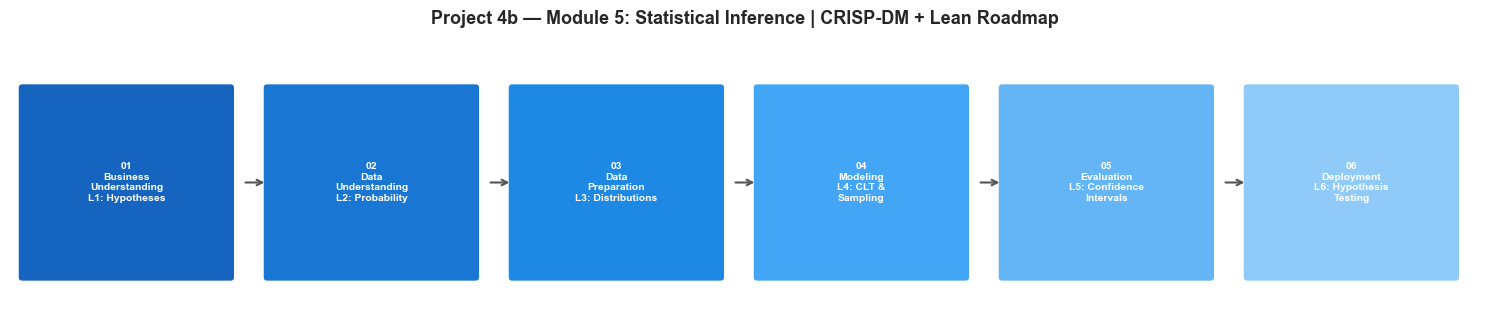

Figure saved: ..\reports\figures\01_crisp_dm_roadmap.png


In [2]:
# ===== CRISP-DM + LEAN Notebook Roadmap Visualization =====

def plot_notebook_roadmap() -> None:
    """Visualizes the 6-notebook analytical roadmap as a CRISP-DM flow diagram.

    Maps each notebook to its CRISP-DM phase and M5 lesson.
    Saves figure to reports/figures/.

    Returns:
        None
    """
    lessons = [
        ('01\nBusiness\nUnderstanding\nL1: Hypotheses', '#1565C0'),
        ('02\nData\nUnderstanding\nL2: Probability', '#1976D2'),
        ('03\nData\nPreparation\nL3: Distributions', '#1E88E5'),
        ('04\nModeling\nL4: CLT &\nSampling', '#42A5F5'),
        ('05\nEvaluation\nL5: Confidence\nIntervals', '#64B5F6'),
        ('06\nDeployment\nL6: Hypothesis\nTesting', '#90CAF9'),
    ]

    fig, ax = plt.subplots(figsize=(15, 3))
    ax.set_xlim(0, len(lessons))
    ax.set_ylim(0, 1)
    ax.axis('off')
    fig.suptitle(
        'Project 4b — Module 5: Statistical Inference | CRISP-DM + Lean Roadmap',
        fontsize=13, fontweight='bold', y=1.02
    )

    for i, (label, color) in enumerate(lessons):
        # Box
        rect = mpatches.FancyBboxPatch(
            (i + 0.05, 0.1), 0.85, 0.8,
            boxstyle='round,pad=0.02',
            facecolor=color, edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)
        ax.text(
            i + 0.475, 0.5, label,
            ha='center', va='center',
            fontsize=7.5, color='white', fontweight='bold'
        )
        # Arrow between boxes
        if i < len(lessons) - 1:
            ax.annotate(
                '', xy=(i + 1.05, 0.5), xytext=(i + 0.95, 0.5),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5)
            )

    plt.tight_layout()
    out = REPORTS_FIGURES / '01_crisp_dm_roadmap.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')


plot_notebook_roadmap()

In [4]:
# ===== Hypotheses Summary Table =====

def build_hypothesis_summary() -> pd.DataFrame:
    """Creates a structured summary of all study hypotheses.

    Returns:
        pd.DataFrame: Hypothesis table with H0, H1, test, alpha,
                      and business implication.
    """
    data = {
        'ID': ['H1', 'H2', 'H3', 'H4'],
        'H0 (Null)': [
            'mu_avg_ticket = 25,000 CLP',
            'mu_ML = mu_Shopify',
            'p_churn = 0.30',
            'mu_Promoter = mu_Passive = mu_Detractor'
        ],
        'H1 (Alternative)': [
            'mu_avg_ticket != 25,000 CLP',
            'mu_ML != mu_Shopify',
            'p_churn > 0.30',
            'At least one group differs'
        ],
        'Statistical Test': [
            'One-sample t-test (two-tailed)',
            'Welch t-test (two-tailed)',
            'Proportion z-test (right-tailed)',
            'One-way ANOVA + Bonferroni'
        ],
        'alpha': [0.05, 0.05, 0.05, 0.05],
        'Notebook': ['06', '06', '06', '06'],
        'Business Decision Enabled': [
            'Pricing vs market benchmark',
            'Channel investment allocation',
            'Retention urgency confirmation',
            'NPS-based pricing segmentation'
        ]
    }
    return pd.DataFrame(data)


df_hypotheses = build_hypothesis_summary()
print('=' * 60)
print('HYPOTHESIS SUMMARY — Project 4b PequeShop')
print('=' * 60)
display(df_hypotheses)

HYPOTHESIS SUMMARY — Project 4b PequeShop


,ID,H0 (Null),H1 (Alternative),Statistical Test,alpha,Notebook,Business Decision Enabled
0,H1,"mu_avg_ticket = 25,000 CLP","mu_avg_ticket != 25,000 CLP",One-sample t-test (two-tailed),0.05,06,Pricing vs market benchmark
1,H2,mu_ML = mu_Shopify,mu_ML != mu_Shopify,Welch t-test (two-tailed),0.05,06,Channel investment allocation
2,H3,p_churn = 0.30,p_churn > 0.30,Proportion z-test (right-tailed),0.05,06,Retention urgency confirmation
3,H4,mu_Promoter = mu_Passive = mu_Detractor,At least one group differs,One-way ANOVA + Bonferroni,0.05,06,NPS-based pricing segmentation


---
## 7. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Does every RQ link to a business decision? | ✅ Yes — all 4 RQs inform budget allocation or pricing | Proceed |
| Is there redundancy between hypotheses? | ✅ No — H1 (market benchmark), H2 (channel), H3 (churn), H4 (NPS) are orthogonal | Proceed |
| Are all selected variables actionable? | ✅ Yes — avg_ticket, churn, NPS are all manageable through campaigns | Proceed |
| Is n=392 sufficient for planned tests? | ✅ Yes — well above CLT threshold (n>>30), adequate power | Proceed |
| Is there a simpler way to answer the business question? | ⚠️ Descriptive stats alone (project-3) were insufficient — inference adds real value | Keep all 4 tests |
| Does project-4b justify project-5? | ✅ Yes — validated features prevent garbage-in, garbage-out in ML | Proceed to M6 |


---
## 8. Decisions Log — Lesson 1

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | Use PequeShop data (synthetic, project-2) instead of new dataset | Maintains pipeline continuity M3→M4→M5→M6 | New Kaggle dataset | ✅ Higher portfolio value |
| 2 | Focus on 4 hypotheses only | Each maps directly to a business decision — avoids exhaustive testing | Testing all variable pairs | ✅ Eliminates waste |
| 3 | H1: two-tailed test for avg_ticket | No prior directional evidence — EDA showed ticket above benchmark but direction not guaranteed | One-tailed | ✅ Conservative and correct |
| 4 | H3: right-tailed test for churn | EDA showed 41.4% > 30% benchmark — direction is clear | Two-tailed | ✅ Directional evidence justifies it |
| 5 | Use census (n=392) not subsample | All active customers available — no reason to subsample | Stratified sample n=100 | ✅ Maximum statistical power |


---
## 9. Next Steps — Lesson 2 Preview

In **Lesson 2 — Data Understanding (notebook 02)**, the following tasks will be completed:

1. Load `customers_final.csv` and `transactions_final.csv` and verify structure
2. Define the sample space (Omega) and random events (churn, promoter, at-risk)
3. Calculate basic probabilities: P(churn), P(promoter), P(promoter | Active)
4. Build probability trees: NPS category × retargeting segment
5. Calculate intersection, union, and complementary events
6. Demonstrate three sampling strategies (random, stratified, systematic)
7. Apply LEAN filter: does each probability calculation inform a hypothesis?

---

**Next Phase -->** [02 - Data Understanding](./02_data_understanding.ipynb)
